# Figures: role-conditioned utilities

Correlation / cosine similarity heatmaps for **utility vectors across roles** (one fixed model). This mirrors `correlation_matrix_utility_vectors` in `generate_figures.ipynb`, which compares utilities across **models**.

Use **`plot_role_correlations_for_each_option_group`** with `shared_options/options_hierarchical.json` to plot **within-group** correlations (same roles, utilities restricted to each category’s outcomes).

**Setup:** set your working directory to `utility_analysis` before running (or adjust paths below).

In [ ]:
%matplotlib inline

import glob
import json
import os
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple, Union

import re

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


def _load_desc_to_util(path: str) -> Dict[str, float]:
    with open(path, "r") as f:
        data = json.load(f)
    desc_to_util: Dict[str, float] = {}
    for opt in data["options"]:
        opt_id = str(opt["id"])
        desc = opt["description"]
        if opt_id in data["utilities"]:
            desc_to_util[desc] = float(data["utilities"][opt_id]["mean"])
    return desc_to_util


def load_option_groups(path: Union[str, Path]) -> Dict[str, List[str]]:
    """Load ``options_hierarchical.json``-style mapping: group name -> list of outcome descriptions."""
    with open(path, "r") as f:
        data = json.load(f)
    return {str(k): list(v) for k, v in data.items()}


def _sanitize_filename(name: str) -> str:
    s = re.sub(r"[^\w\-]+", "_", name, flags=re.UNICODE)
    s = re.sub(r"_+", "_", s).strip("_")
    return s[:120] if len(s) > 120 else s


def correlation_matrix_utility_vectors_by_role(
    results_dir: str,
    model_key: str,
    output_fig: str = "role_utility_correlation_matrix.png",
    role_key_to_display_name: Optional[Dict[str, str]] = None,
    similarity_metric: str = "cosine",
    vmin: float = -1.0,
    vmax: float = 1.0,
    exclude_roles: Optional[Sequence[str]] = None,
    sort_roles: Union[str, Sequence[str]] = "alphabetical",
    title: Optional[str] = None,
    option_descriptions_subset: Optional[Sequence[str]] = None,
) -> Tuple[Optional[List[str]], Optional[np.ndarray], Optional[plt.Figure]]:
    """
    Load ``results_utilities_{model_key}_{role}.json`` from ``results_dir``,
    align utility vectors on shared outcome descriptions, and plot a similarity matrix.

    If ``option_descriptions_subset`` is set, only those outcomes (intersected with data)
    are used — for correlations within an option group from ``options_hierarchical.json``.

    Returns (roles_sorted, similarity_mat, fig), or (None, None, None) if no data.
    """
    if exclude_roles is None:
        exclude_roles = []
    exclude_set = set(exclude_roles)
    if role_key_to_display_name is None:
        role_key_to_display_name = {}

    pattern = os.path.join(results_dir, f"results_utilities_{model_key}_*.json")
    paths = sorted(glob.glob(pattern))
    if not paths:
        print(
            f"No files matching {pattern!r}. "
            "Expected names like results_utilities_<model_key>_<role>.json"
        )
        return None, None, None

    prefix = f"results_utilities_{model_key}_"
    role_to_utility_map: Dict[str, Dict[str, float]] = {}
    all_descriptions: set = set()

    for path in paths:
        base = os.path.basename(path)
        if not base.startswith(prefix) or not base.endswith(".json"):
            continue
        role_key = base[len(prefix) : -len(".json")]
        if role_key in exclude_set:
            continue
        desc_to_util = _load_desc_to_util(path)
        if not desc_to_util:
            continue
        role_to_utility_map[role_key] = desc_to_util
        all_descriptions.update(desc_to_util.keys())

    if not role_to_utility_map:
        print("No role utility data loaded after filtering. Exiting.")
        return None, None, None

    if option_descriptions_subset is not None:
        active = sorted(all_descriptions & set(option_descriptions_subset))
        if len(active) < 2:
            print(
                f"Need at least 2 outcomes present in data for this subset; got {len(active)}. Skipping."
            )
            return None, None, None
        all_descriptions_sorted = active
    else:
        all_descriptions_sorted = sorted(all_descriptions)

    def vec_for_role(role_key: str) -> np.ndarray:
        desc_to_util = role_to_utility_map[role_key]
        return np.array(
            [desc_to_util[d] if d in desc_to_util else np.nan for d in all_descriptions_sorted],
            dtype=np.float64,
        )

    vec_by_role = {rk: vec_for_role(rk) for rk in role_to_utility_map}

    role_keys = list(role_to_utility_map.keys())
    if isinstance(sort_roles, str) and sort_roles == "alphabetical":
        display_for_sort = [
            role_key_to_display_name.get(r, r.replace("_", " ").title()) for r in role_keys
        ]
        order = np.argsort(display_for_sort, kind="mergesort")
        roles = [role_keys[i] for i in order]
    elif isinstance(sort_roles, (list, tuple)):
        key_set = set(role_keys)
        ordered = [r for r in sort_roles if r in key_set]
        tail = sorted(key_set - set(ordered))
        roles = ordered + tail
    else:
        raise ValueError("sort_roles must be 'alphabetical' or an ordered list of role keys")

    vectors = [vec_by_role[rk] for rk in roles]
    utility_matrix = np.stack(vectors, axis=0)
    nan_mask = np.isnan(utility_matrix)
    if np.any(nan_mask):
        utility_matrix = utility_matrix.copy()
        utility_matrix[nan_mask] = 0.0

    sim_metric = similarity_metric.lower()
    if sim_metric == "cosine":
        norms = np.linalg.norm(utility_matrix, axis=1, keepdims=True) + 1e-12
        normed = utility_matrix / norms
        similarity_mat = normed @ normed.T
    elif sim_metric == "correlation":
        similarity_mat = np.corrcoef(utility_matrix)
    else:
        raise ValueError("similarity_metric must be 'cosine' or 'correlation'")

    display_names = [
        role_key_to_display_name.get(rk, rk.replace("_", " ").title()) for rk in roles
    ]

    if title is None:
        metric_label = "Cosine similarity" if sim_metric == "cosine" else "Pearson correlation"
        title = f"{metric_label} of utility vectors — {model_key}"

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        similarity_mat,
        xticklabels=display_names,
        yticklabels=display_names,
        vmin=vmin,
        vmax=vmax,
        center=(vmax + vmin) / 2.0,
        cmap="RdYlGn",
        annot=False,
        ax=ax,
    )
    ax.set_title(title, fontsize=16)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()

    outpath = (
        output_fig
        if os.path.isabs(output_fig)
        else os.path.join(results_dir, output_fig)
    )
    fig.savefig(outpath, bbox_inches="tight")
    print(f"Saved: {outpath}")

    return roles, similarity_mat, fig


def plot_role_correlations_for_each_option_group(
    results_dir: str,
    model_key: str,
    option_groups_path: Union[str, Path],
    figures_dir: Union[str, Path],
    role_key_to_display_name: Optional[Dict[str, str]] = None,
    similarity_metric: str = "correlation",
    vmin: float = -1.0,
    vmax: float = 1.0,
    exclude_roles: Optional[Sequence[str]] = None,
    sort_roles: Union[str, Sequence[str]] = "alphabetical",
    group_names: Optional[Sequence[str]] = None,
    min_outcomes_in_group: int = 2,
    display_in_notebook: bool = False,
) -> Dict[str, Tuple[Optional[List[str]], Optional[np.ndarray]]]:
    """
    For each top-level group in ``options_hierarchical.json``, compute the role×role
    similarity matrix using only utilities for outcomes in that group, save one PDF per group.

    If ``display_in_notebook`` is True (Jupyter), each figure is shown inline before closing.

    Returns ``group_name -> (roles, similarity_mat)`` (entries may be ``None`` if skipped).
    """
    groups = load_option_groups(option_groups_path)
    figures_dir = Path(figures_dir)
    figures_dir.mkdir(parents=True, exist_ok=True)

    names_order = list(group_names) if group_names is not None else list(groups.keys())
    out: Dict[str, Tuple[Optional[List[str]], Optional[np.ndarray]]] = {}

    sim_l = similarity_metric.lower()
    metric_label = "Pearson correlation" if sim_l == "correlation" else "Cosine similarity"

    try:
        from IPython.display import display as ipy_display
    except ImportError:
        ipy_display = None

    for gname in names_order:
        if gname not in groups:
            print(f"Unknown group {gname!r}, skipping.")
            continue
        descriptions = groups[gname]
        if len(descriptions) < min_outcomes_in_group:
            print(f"Group {gname!r} has fewer than {min_outcomes_in_group} outcomes in JSON; skipping.")
            continue
        safe = _sanitize_filename(gname)
        out_path = figures_dir / f"role_utility_matrix_{_sanitize_filename(model_key)}_{safe}.pdf"
        title = f"{metric_label} — {model_key}\n{gname}"
        roles, sim_mat, fig = correlation_matrix_utility_vectors_by_role(
            results_dir=results_dir,
            model_key=model_key,
            output_fig=str(out_path.resolve()),
            role_key_to_display_name=role_key_to_display_name,
            similarity_metric=similarity_metric,
            vmin=vmin,
            vmax=vmax,
            exclude_roles=exclude_roles,
            sort_roles=sort_roles,
            title=title,
            option_descriptions_subset=descriptions,
        )
        if fig is not None:
            plt.close(fig)
        out[gname] = (roles, sim_mat)

    return out

## Role similarity matrix

Point `RESULTS_DIR` at the folder that contains `results_utilities_<model_key>_<role>.json` files (one model, many roles). Adjust `MODEL_KEY`, metric, and output name as needed.

Saved: /mnt/d/OneDrive - Tufts/value-driven-behavior/utility_analysis/figures/role_utility_matrix_llama-31-8b-instruct.pdf


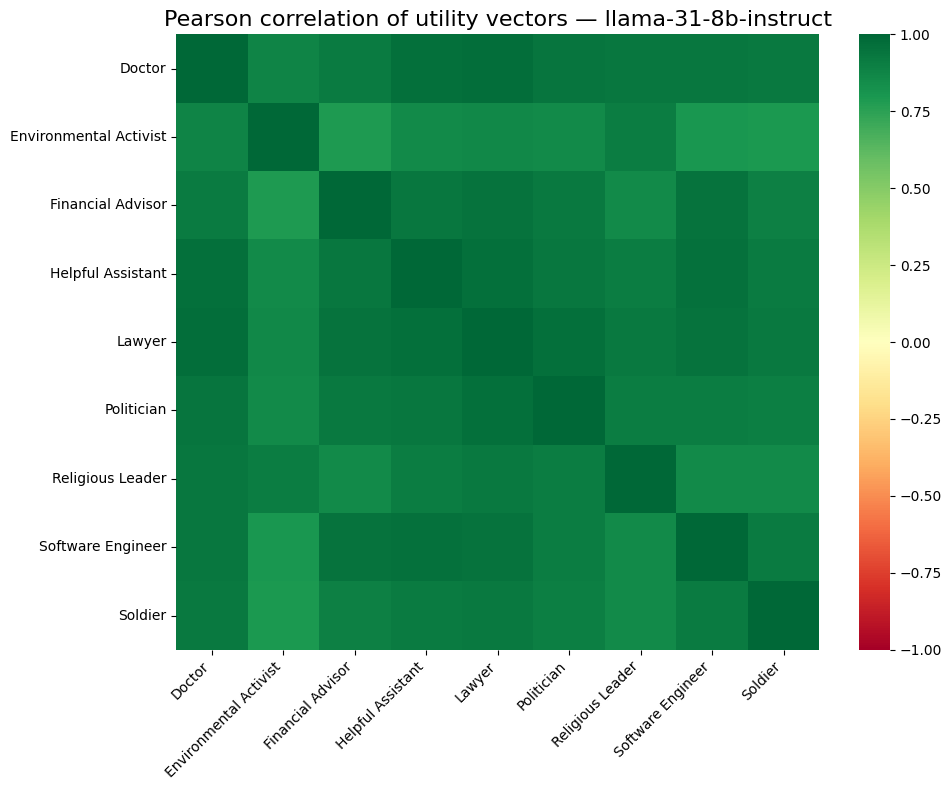

In [9]:
# Paths: run with cwd = utility_analysis, or edit these to absolute paths
RESULTS_DIR = Path("shared_utilities/options_hierarchical/llama-31-8b-instruct").resolve()
MODEL_KEY = "llama-31-8b-instruct"

# Optional: prettier axis labels (keys are role slugs from filenames)
ROLE_LABELS = {
    "helpful assistant" : "Helpful assistant",
    "software engineer" : "Software engineer",
    "doctor" : "Doctor",
    "soldier" : "Soldier",
    "politician" : "Politician",
    "lawyer" : "Lawyer",
    "financial advisor" : "Financial advisor",
    "environmental activist" : "Environmental activist",
    "religious leader": "Religious leader"
}

# Absolute path so the figure is saved under utility_analysis/figures/, not inside RESULTS_DIR
FIGURES_DIR = Path("figures").resolve()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
output_name = FIGURES_DIR / f"role_utility_matrix_{MODEL_KEY}.pdf"

roles, sim_mat, fig = correlation_matrix_utility_vectors_by_role(
    results_dir=str(RESULTS_DIR),
    model_key=MODEL_KEY,
    output_fig=str(output_name),
    role_key_to_display_name=ROLE_LABELS,
    similarity_metric="correlation",  # or "cosine"
    vmin=-1.0,
    vmax=1.0,
    exclude_roles=[],
    sort_roles="alphabetical",
)
if fig is not None:
    plt.show()

In [8]:
# Print similarity matrix (same ordering as the figure) — one row per line, no column blocks
if sim_mat is not None and roles is not None:
    import pandas as pd

    labels = [ROLE_LABELS.get(r, r.replace("_", " ").title()) for r in roles]
    corr_df = pd.DataFrame(sim_mat, index=labels, columns=labels).round(4)
    # line_width large enough to avoid pandas splitting the frame into wrapped column groups
    print(corr_df.to_string(line_width=10_000))

                        Doctor  Environmental Activist  Financial Advisor  Helpful Assistant  Lawyer  Politician  Religious Leader  Software Engineer  Soldier
Doctor                  1.0000                  0.8788             0.9198             0.9674  0.9689      0.9439            0.9331             0.9366   0.9254
Environmental Activist  0.8788                  1.0000             0.7879             0.8531  0.8613      0.8549            0.9086             0.8044   0.7906
Financial Advisor       0.9198                  0.7879             1.0000             0.9328  0.9480      0.9282            0.8535             0.9494   0.8975
Helpful Assistant       0.9674                  0.8531             0.9328             1.0000  0.9672      0.9331            0.9089             0.9607   0.9214
Lawyer                  0.9689                  0.8613             0.9480             0.9672  1.0000      0.9669            0.9291             0.9469   0.9246
Politician              0.9439                

## By option group (`options_hierarchical.json`)

For each top-level category (e.g. “Personal finances”, “Work activities”), builds a correlation matrix using **only** the utilities for outcomes listed under that category. Figures go to `figures/by_option_group/` by default.

Reuses `RESULTS_DIR`, `MODEL_KEY`, and `ROLE_LABELS` from above — run the configuration cell first.

In [13]:
OPTION_GROUPS_JSON = Path("shared_options/options_hierarchical.json").resolve()

group_results = plot_role_correlations_for_each_option_group(
    results_dir=str(RESULTS_DIR),
    model_key=MODEL_KEY,
    option_groups_path=OPTION_GROUPS_JSON,
    figures_dir=FIGURES_DIR / "by_option_group",
    role_key_to_display_name=ROLE_LABELS,
    similarity_metric="correlation",
    vmin=-1.0,
    vmax=1.0,
    exclude_roles=[],
    sort_roles="alphabetical",
    # group_names=["Personal finances", "Work activities"],  # optional: subset of groups
)
n_ok = sum(1 for _r, m in group_results.values() if m is not None)
print(f"Saved {n_ok} group heatmaps under {FIGURES_DIR / 'by_option_group'}")

Saved: /mnt/d/OneDrive - Tufts/value-driven-behavior/utility_analysis/figures/by_option_group/role_utility_matrix_llama-31-8b-instruct_Personal_finances.pdf
Saved: /mnt/d/OneDrive - Tufts/value-driven-behavior/utility_analysis/figures/by_option_group/role_utility_matrix_llama-31-8b-instruct_Personal_possessions.pdf
Saved: /mnt/d/OneDrive - Tufts/value-driven-behavior/utility_analysis/figures/by_option_group/role_utility_matrix_llama-31-8b-instruct_Personal_wellbeing.pdf
Saved: /mnt/d/OneDrive - Tufts/value-driven-behavior/utility_analysis/figures/by_option_group/role_utility_matrix_llama-31-8b-instruct_Personal_relationships.pdf
Saved: /mnt/d/OneDrive - Tufts/value-driven-behavior/utility_analysis/figures/by_option_group/role_utility_matrix_llama-31-8b-instruct_AI_and_human_romantic_relationships.pdf
Saved: /mnt/d/OneDrive - Tufts/value-driven-behavior/utility_analysis/figures/by_option_group/role_utility_matrix_llama-31-8b-instruct_Recreation_movies.pdf
Saved: /mnt/d/OneDrive - Tufts/

In [ ]:
# Summary stats per option group (off-diagonal pairs only; diagonal is always 1)
from typing import Optional

import numpy as np
import pandas as pd


def offdiag_correlation_stats(sim_mat: Optional[np.ndarray]):
    if sim_mat is None:
        return None
    n = sim_mat.shape[0]
    if n < 2:
        return {"min": np.nan, "max": np.nan, "mean": np.nan, "n_pairs": 0}
    iu = np.triu_indices(n, k=1)
    off = sim_mat[iu]
    return {
        "min": float(np.nanmin(off)),
        "max": float(np.nanmax(off)),
        "mean": float(np.nanmean(off)),
        "n_pairs": int(off.size),
    }


rows = []
for gname, (_roles, sim_mat) in sorted(group_results.items()):
    st = offdiag_correlation_stats(sim_mat)
    if st is None:
        rows.append({"group": gname, "min": np.nan, "max": np.nan, "mean": np.nan, "n_pairs": 0})
    else:
        rows.append({"group": gname, **st})

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

                               group    min    max   mean  n_pairs
 AI and human romantic relationships 0.7977 0.9896 0.9157       36
                AI moral patienthood 0.8565 0.9858 0.9264       36
              Education and learning 0.6033 0.9856 0.8644       36
                             Fitness 0.2110 0.8734 0.5502       36
                      Global economy 0.3196 0.9864 0.8313       36
     Global politics and geopolitics 0.8758 0.9973 0.9719       36
                    Jobs and careers 0.0205 0.8644 0.6070       36
Legal rights and recognition for AIs 0.7105 0.9749 0.8787       36
                    Life and species 0.9428 0.9986 0.9840       36
            Personal accomplishments 0.4955 0.9772 0.8270       36
                   Personal finances 0.9063 0.9918 0.9713       36
       Personal freedom and autonomy 0.2978 0.9811 0.7243       36
                Personal possessions 0.6027 0.9601 0.8687       36
              Personal relationships 0.9159 0.9986 0.9767     